In [15]:
import pandas as pd
import numpy as np

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [16]:
student_skill = pd.read_csv(
    "../data/processed/student_skill_features.csv"
)

print(student_skill.shape)
student_skill.head()

(41576, 8)


,user_id,skill_name,Accuracy,Avg_Attempts,Avg_Hints,Avg_Response_Time,Questions_Attempted,Max_Opportunity
0,14,Circle Graph,0.250000,0.75,1.083333,32656.750000,12,12
1,14,Equivalent Fractions,0.333333,0.50,0.500000,47747.333333,6,6
2,14,Finding Percents,0.000000,0.50,1.500000,24554.500000,2,2
3,14,Median,0.000000,1.00,2.500000,6697.250000,4,4
4,14,Percent Of,0.166667,1.00,1.666667,17566.166667,6,6


In [17]:
student_skill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41576 entries, 0 to 41575
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              41576 non-null  int64  
 1   skill_name           41576 non-null  object 
 2   Accuracy             41576 non-null  float64
 3   Avg_Attempts         41576 non-null  float64
 4   Avg_Hints            41576 non-null  float64
 5   Avg_Response_Time    41576 non-null  float64
 6   Questions_Attempted  41576 non-null  int64  
 7   Max_Opportunity      41576 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 2.5+ MB


In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

student_skill[
    [
        "Accuracy_Norm",
        "Attempts_Norm",
        "Hints_Norm",
        "ResponseTime_Norm"
    ]
] = scaler.fit_transform(
    student_skill[
        [
            "Accuracy",
            "Avg_Attempts",
            "Avg_Hints",
            "Avg_Response_Time"
        ]
    ]
)

In [19]:
student_skill["KnowledgeGapScore"] = (
    (1 - student_skill["Accuracy_Norm"]) * 0.50 +
    student_skill["Attempts_Norm"] * 0.20 +
    student_skill["Hints_Norm"] * 0.20 +
    student_skill["ResponseTime_Norm"] * 0.10
)

In [20]:
student_skill["KnowledgeGapScore"].describe()

count    41576.000000
mean         0.162486
std          0.175731
min          0.002612
25%          0.003066
50%          0.118083
75%          0.253014
max          0.766439
Name: KnowledgeGapScore, dtype: float64

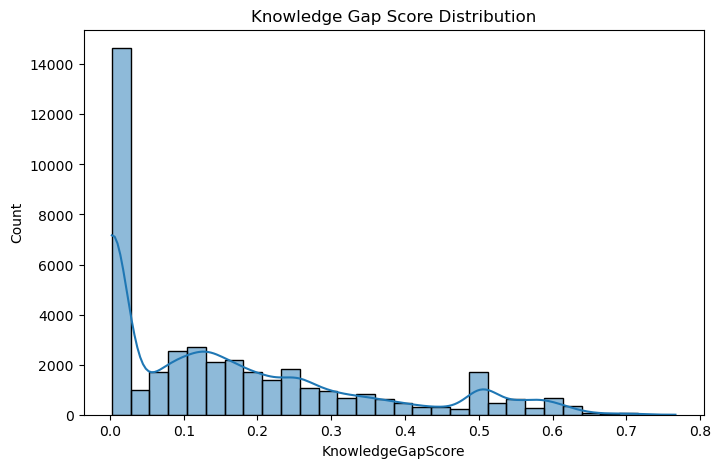

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    student_skill["KnowledgeGapScore"],
    bins=30,
    kde=True
)

plt.title("Knowledge Gap Score Distribution")

plt.show()

In [22]:
student_skill["KnowledgeGap"] = pd.qcut(
    student_skill["KnowledgeGapScore"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [23]:
print(student_skill["KnowledgeGap"].value_counts())

KnowledgeGap
Low       13860
High      13859
Medium    13857
Name: count, dtype: int64


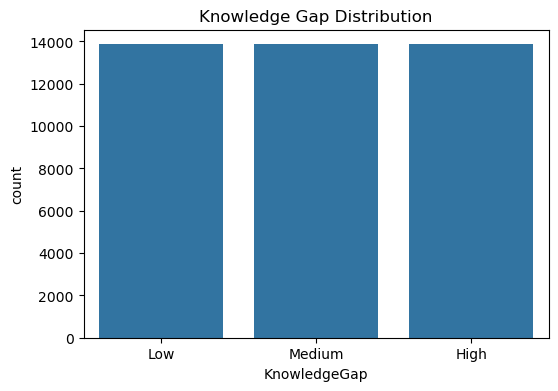

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=student_skill,
    x="KnowledgeGap",
    order=["Low", "Medium", "High"]
)

plt.title("Knowledge Gap Distribution")

plt.show()

In [25]:
student_skill[
    [
        "user_id",
        "skill_name",
        "Accuracy",
        "Avg_Attempts",
        "Avg_Hints",
        "KnowledgeGapScore",
        "KnowledgeGap"
    ]
].head(20)

,user_id,skill_name,Accuracy,Avg_Attempts,Avg_Hints,KnowledgeGapScore,KnowledgeGap
0,14,Circle Graph,0.250000,0.750000,1.083333,0.408869,High
1,14,Equivalent Fractions,0.333333,0.500000,0.500000,0.350614,High
2,14,Finding Percents,0.000000,0.500000,1.500000,0.545692,High
3,14,Median,0.000000,1.000000,2.500000,0.574192,High
4,14,Percent Of,0.166667,1.000000,1.666667,0.467124,High
5,14,Proportion,0.000000,0.000000,0.000000,0.503106,High
6,14,Range,1.000000,1.000000,0.000000,0.002796,Low
7,14,Unknown Skill,0.250000,1.187500,1.437500,0.418938,High
8,21825,Mean,0.750000,1.000000,0.000000,0.128134,Medium
9,21825,Median,0.333333,0.666667,0.000000,0.337050,High


In [26]:
student_skill.sort_values(
    by="KnowledgeGapScore",
    ascending=False
).head(20)

,user_id,skill_name,Accuracy,Avg_Attempts,Avg_Hints,Avg_Response_Time,Questions_Attempted,Max_Opportunity,Accuracy_Norm,Attempts_Norm,Hints_Norm,ResponseTime_Norm,KnowledgeGapScore,KnowledgeGap
31289,88029,Division Fractions,0.0,1426.000000,4.0,60185.0,1,1,0.0,0.745621,0.571429,0.030293,0.766439,High
23949,83208,Conversion of Fraction Decimals Percents,0.0,1912.500000,1.5,98021.0,2,2,0.0,1.000000,0.214286,0.032915,0.746149,High
6131,78413,Rotations,0.0,3.500000,7.0,417082.5,2,2,0.0,0.001830,1.000000,0.055025,0.705868,High
1765,70816,Rotations,0.0,1.000000,7.0,377188.0,1,1,0.0,0.000523,1.000000,0.052260,0.705331,High
6285,78449,Rotations,0.0,1.000000,7.0,317169.0,1,1,0.0,0.000523,1.000000,0.048101,0.704915,High
742,70707,Rotations,0.0,5.000000,7.0,223766.0,1,1,0.0,0.002614,1.000000,0.041629,0.704686,High
38594,96253,Rotations,0.0,16.000000,7.0,47452.0,1,1,0.0,0.008366,1.000000,0.029411,0.704614,High
11815,78989,Rotations,0.0,16.000000,7.0,47452.0,1,1,0.0,0.008366,1.000000,0.029411,0.704614,High
28956,85952,Surface Area Rectangular Prism,0.0,1.000000,7.0,249598.0,1,1,0.0,0.000523,1.000000,0.043419,0.704446,High
32920,89116,Rotations,0.0,8.666667,7.0,127045.0,3,3,0.0,0.004532,1.000000,0.034926,0.704399,High


In [27]:
student_skill.to_csv(
    "../data/processed/knowledge_gap_dataset.csv",
    index=False
)

print("Knowledge Gap Dataset Saved Successfully!")

Knowledge Gap Dataset Saved Successfully!


In [28]:
print("="*60)
print("KNOWLEDGE GAP DETECTION COMPLETED")
print("="*60)

print(student_skill["KnowledgeGap"].value_counts())

print("="*60)

KNOWLEDGE GAP DETECTION COMPLETED
KnowledgeGap
Low       13860
High      13859
Medium    13857
Name: count, dtype: int64


In [29]:
student_skill["WeakSkill"] = np.where(
    student_skill["KnowledgeGap"] == "High",
    student_skill["skill_name"],
    "None"
)

student_skill.head()

,user_id,skill_name,Accuracy,Avg_Attempts,Avg_Hints,Avg_Response_Time,Questions_Attempted,Max_Opportunity,Accuracy_Norm,Attempts_Norm,Hints_Norm,ResponseTime_Norm,KnowledgeGapScore,KnowledgeGap,WeakSkill
0,14,Circle Graph,0.250000,0.75,1.083333,32656.750000,12,12,0.250000,0.000392,0.154762,0.028386,0.408869,High,Circle Graph
1,14,Equivalent Fractions,0.333333,0.50,0.500000,47747.333333,6,6,0.333333,0.000261,0.071429,0.029431,0.350614,High,Equivalent Fractions
2,14,Finding Percents,0.000000,0.50,1.500000,24554.500000,2,2,0.000000,0.000261,0.214286,0.027824,0.545692,High,Finding Percents
3,14,Median,0.000000,1.00,2.500000,6697.250000,4,4,0.000000,0.000523,0.357143,0.026587,0.574192,High,Median
4,14,Percent Of,0.166667,1.00,1.666667,17566.166667,6,6,0.166667,0.000523,0.238095,0.027340,0.467124,High,Percent Of


In [30]:
student_skill.to_csv(
    "../data/processed/knowledge_gap_dataset.csv",
    index=False
)

print("Knowledge Gap Dataset Updated Successfully!")

Knowledge Gap Dataset Updated Successfully!


In [31]:
student_skill = student_skill.sort_values(
    by=["user_id", "KnowledgeGapScore"],
    ascending=[True, False]
).reset_index(drop=True)

student_skill.to_csv(
    "../data/processed/knowledge_gap_dataset.csv",
    index=False
)

student_skill.head()

,user_id,skill_name,Accuracy,Avg_Attempts,Avg_Hints,Avg_Response_Time,Questions_Attempted,Max_Opportunity,Accuracy_Norm,Attempts_Norm,Hints_Norm,ResponseTime_Norm,KnowledgeGapScore,KnowledgeGap,WeakSkill
0,14,Median,0.000000,1.0000,2.500000,6697.250000,4,4,0.000000,0.000523,0.357143,0.026587,0.574192,High,Median
1,14,Finding Percents,0.000000,0.5000,1.500000,24554.500000,2,2,0.000000,0.000261,0.214286,0.027824,0.545692,High,Finding Percents
2,14,Proportion,0.000000,0.0000,0.000000,71231.500000,2,2,0.000000,0.000000,0.000000,0.031059,0.503106,High,Proportion
3,14,Percent Of,0.166667,1.0000,1.666667,17566.166667,6,6,0.166667,0.000523,0.238095,0.027340,0.467124,High,Percent Of
4,14,Unknown Skill,0.250000,1.1875,1.437500,18846.625000,16,10,0.250000,0.000621,0.205357,0.027429,0.418938,High,Unknown Skill
